In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
train = pd.read_csv("../data/train.csv")
stores = pd.read_csv("../data/stores.csv")
holidays = pd.read_csv("../data/holidays_events.csv")

# Preview
print(train.head())

print("\nShape:")
print(train.shape)

print("\nInfo:")
print(train.info())

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Shape:
(3000888, 6)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 196.8 MB
None


In [2]:
# Convert date column to datetime
train["date"] = pd.to_datetime(train["date"])

# Check missing values
print("Missing Values:")
print(train.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(train.describe())

# Check duplicate rows
print("\nDuplicate Rows:")
print(train.duplicated().sum())

Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Descriptive Statistics:
                 id                        date     store_nbr         sales  \
count  3.000888e+06                     3000888  3.000888e+06  3.000888e+06   
mean   1.500444e+06  2015-04-24 08:27:04.703088  2.750000e+01  3.577757e+02   
min    0.000000e+00         2013-01-01 00:00:00  1.000000e+00  0.000000e+00   
25%    7.502218e+05         2014-02-26 18:00:00  1.400000e+01  0.000000e+00   
50%    1.500444e+06         2015-04-24 12:00:00  2.750000e+01  1.100000e+01   
75%    2.250665e+06         2016-06-19 06:00:00  4.100000e+01  1.958473e+02   
max    3.000887e+06         2017-08-15 00:00:00  5.400000e+01  1.247170e+05   
std    8.662819e+05                         NaN  1.558579e+01  1.101998e+03   

        onpromotion  
count  3.000888e+06  
mean   2.602770e+00  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00  


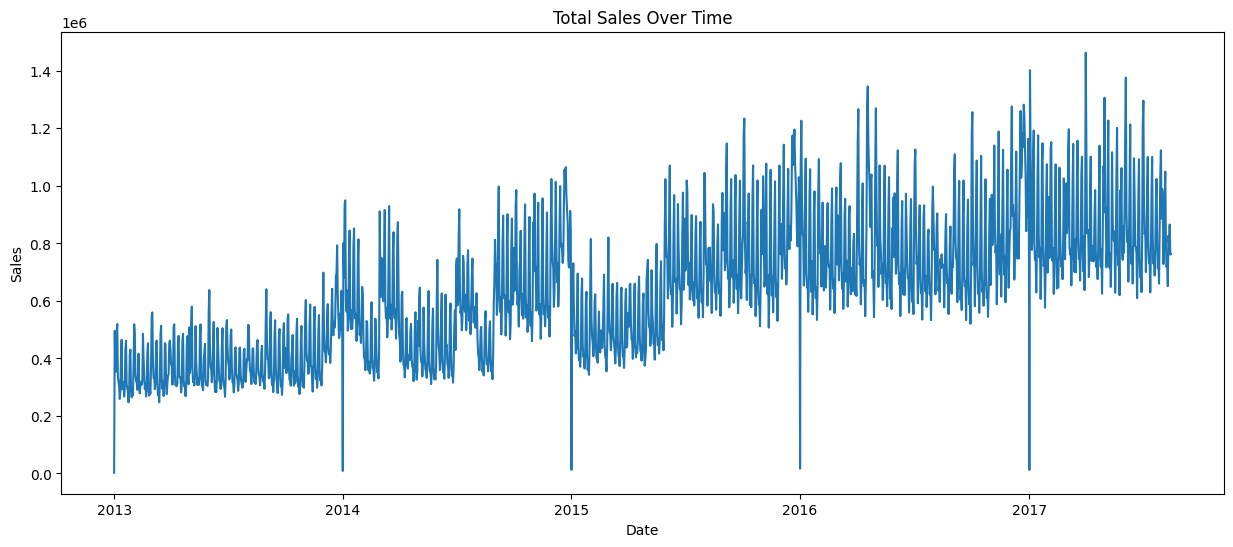

In [3]:
# Group sales by date
daily_sales = train.groupby("date")["sales"].sum()

# Plot sales trend
plt.figure(figsize=(15,6))
plt.plot(daily_sales.index, daily_sales.values)

plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

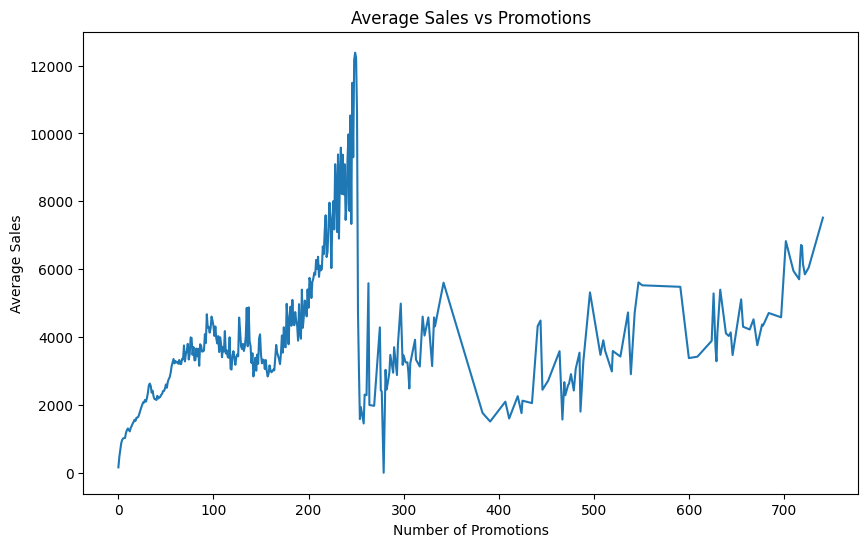

In [ ]:
#PROMOTION VS SALES
# Group by promotion count
promo_sales = train.groupby("onpromotion")["sales"].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))
plt.plot(promo_sales["onpromotion"], promo_sales["sales"])

plt.title("Average Sales vs Promotions")
plt.xlabel("Number of Promotions")
plt.ylabel("Average Sales")

plt.show()

In [5]:
#FEATURE ENGINEERING
# Create date-based features
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["weekday"] = train["date"].dt.weekday

# Weekend flag
train["is_weekend"] = train["weekday"].isin([5, 6]).astype(int)

# Lag feature (previous day's sales)
train["lag_1"] = train.groupby(["store_nbr", "family"])["sales"].shift(1)

# Rolling average feature
train["rolling_mean_7"] = (
    train.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda x: x.rolling(7).mean())
)

# Preview new features
print(train.head(10))

   id       date  store_nbr        family  sales  onpromotion  year  month  \
0   0 2013-01-01          1    AUTOMOTIVE    0.0            0  2013      1   
1   1 2013-01-01          1     BABY CARE    0.0            0  2013      1   
2   2 2013-01-01          1        BEAUTY    0.0            0  2013      1   
3   3 2013-01-01          1     BEVERAGES    0.0            0  2013      1   
4   4 2013-01-01          1         BOOKS    0.0            0  2013      1   
5   5 2013-01-01          1  BREAD/BAKERY    0.0            0  2013      1   
6   6 2013-01-01          1   CELEBRATION    0.0            0  2013      1   
7   7 2013-01-01          1      CLEANING    0.0            0  2013      1   
8   8 2013-01-01          1         DAIRY    0.0            0  2013      1   
9   9 2013-01-01          1          DELI    0.0            0  2013      1   

   day  weekday  is_weekend  lag_1  rolling_mean_7  
0    1        1           0    NaN             NaN  
1    1        1           0    NaN 

In [6]:
#CLEAN MODEL
# Remove rows with NaN values
train = train.dropna()

# Check remaining missing values
print(train.isnull().sum())

# Check new shape
print("\nNew Shape:")
print(train.shape)

id                0
date              0
store_nbr         0
family            0
sales             0
onpromotion       0
year              0
month             0
day               0
weekday           0
is_weekend        0
lag_1             0
rolling_mean_7    0
dtype: int64

New Shape:
(2990196, 13)


In [7]:
# One-hot encode family column
train = pd.get_dummies(train, columns=["family"], drop_first=True)

print(train.head())

          id       date  store_nbr   sales  onpromotion  year  month  day  \
10692  10692 2013-01-07          1     0.0            0  2013      1    7   
10693  10693 2013-01-07          1     0.0            0  2013      1    7   
10694  10694 2013-01-07          1     1.0            0  2013      1    7   
10695  10695 2013-01-07          1  1158.0            0  2013      1    7   
10696  10696 2013-01-07          1     0.0            0  2013      1    7   

       weekday  is_weekend  ...  family_MAGAZINES  family_MEATS  \
10692        0           0  ...             False         False   
10693        0           0  ...             False         False   
10694        0           0  ...             False         False   
10695        0           0  ...             False         False   
10696        0           0  ...             False         False   

       family_PERSONAL CARE  family_PET SUPPLIES  \
10692                 False                False   
10693                 False   

In [8]:
#PREPARE FEATURES AND TARGETS
from sklearn.model_selection import train_test_split

# Features (X)
X = train.drop(columns=["sales", "date"])

# Target (y)
y = train["sales"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (2392156, 42)
Testing set shape: (598040, 42)


In [9]:
#TRAIN MULTIPLE LINEAR REGRESSION MODELS
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [10]:
#PREDICTION + EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 107.39101753543062
RMSE: 332.5081125875232
R² Score: 0.9094733144903172


In [11]:
import joblib

# Save model
joblib.dump(model, "../app/sales_model.pkl")

print("Model saved successfully!")

Model saved successfully!
